# Urban Safety — Risk Score Calculation

Computes a normalized risk score from the filtered feature dataset, classifies segments into risk bands, and exports the scored output.

**Input:** `csv/features_all_boroughs_with_location_id_augmented.csv`  
**Output:** `csv/segment_risk_scores_w-id.csv`

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(rc={'figure.figsize': (8, 8)})
pd.set_option('display.float_format', '{:.3f}'.format)

FEATURES_CACHE = os.path.join('..', 'csv', 'features_all_boroughs_with_location_id_augmented.csv')
OUTPUT_PATH = os.path.join('..', 'csv', 'segment_risk_scores_w-id.csv')

ALLOWED_BOROUGH_NAMES = [
    'City of Westminster, London, UK',
    'London Borough of Islington, London, UK',
    'London Borough of Hackney, London, UK',
    'London Borough of Tower Hamlets, London, UK',
    'London Borough of Southwark, London, UK',
]

FEATURE_COLS = ['lighting', 'visibility', 'connectivity', 'enclosure', 'public_transport_proximity_m', 'dominant_land_use_score']

## Load Filtered Features
Loads the prepared feature CSV and keeps only the five target boroughs.

In [2]:
features = pd.read_csv(FEATURES_CACHE)
if 'borough' in features.columns:
    before = len(features)
    features = features[features['borough'].isin(ALLOWED_BOROUGH_NAMES)].reset_index(drop=True)
    after = len(features)
    print(f'✓ Loaded {after:,} segments from {FEATURES_CACHE} (filtered from {before:,})')
    print(f'  Boroughs : {features["borough"].nunique()}')
    print(features['borough'].value_counts().to_string())
else:
    print(f'✓ Loaded {len(features):,} segments from {FEATURES_CACHE} (no borough column to filter)')

✓ Loaded 35,978 segments from ..\csv\features_all_boroughs_with_location_id_augmented.csv (filtered from 61,784)
  Boroughs : 5
borough
London Borough of Southwark, London, UK        9757
London Borough of Tower Hamlets, London, UK    7618
City of Westminster, London, UK                7558
London Borough of Hackney, London, UK          5863
London Borough of Islington, London, UK        5182


## Risk Score Formula
Each feature is first converted to a $[0, 1]$ risk component, where larger values always mean higher risk. Those components are then combined with positive weights into a final risk score in the $[0, 1]$ range.

In [3]:
# Per-feature normalization: create <feature>_norm columns for export and scoring
def norm_col(series, clip=None):
    s = series.astype(float).copy()
    if clip is not None:
        s = s.clip(upper=clip)
    if s.isna().all():
        return pd.Series(0.0, index=s.index)
    s = s.fillna(s.median())
    mn = s.min()
    mx = s.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(0.0, index=s.index)
    return (s - mn) / (mx - mn)

# Normalize basic features (use zeros if column missing)
features['lighting_norm'] = norm_col(features['lighting'] if 'lighting' in features.columns else pd.Series(0.0, index=features.index))
features['visibility_norm'] = norm_col(features['visibility'] if 'visibility' in features.columns else pd.Series(0.0, index=features.index))
features['connectivity_norm'] = norm_col(features['connectivity'] if 'connectivity' in features.columns else pd.Series(0.0, index=features.index))
features['enclosure_norm'] = norm_col(features['enclosure'] if 'enclosure' in features.columns else pd.Series(0.0, index=features.index))

# Transport proximity: keep existing behavior (use public_transport_proximity_m or nearest of rail/bus), clip at 800m
if 'public_transport_proximity_m' in features.columns:
    transport_raw = features['public_transport_proximity_m']
elif {'dist_to_rail_m', 'dist_to_bus_m'}.issubset(features.columns):
    transport_raw = features[['dist_to_rail_m', 'dist_to_bus_m']].min(axis=1)
else:
    transport_raw = pd.Series(0.0, index=features.index)
features['public_transport_proximity_m_norm'] = norm_col(transport_raw, clip=800)

# Dominant land use score (or commercial ratio fallback)
if 'dominant_land_use_score' in features.columns:
    landuse_raw = features['dominant_land_use_score']
elif 'commercial_ratio' in features.columns:
    landuse_raw = features['commercial_ratio']
else:
    landuse_raw = pd.Series(0.0, index=features.index)
features['dominant_land_use_score_norm'] = norm_col(landuse_raw)

print('✓ Created normalized feature columns:', ', '.join([c for c in features.columns if c.endswith('_norm')]))

✓ Created normalized feature columns: lighting_norm, visibility_norm, connectivity_norm, enclosure_norm, public_transport_proximity_m_norm, dominant_land_use_score_norm


In [4]:
def compute_risk_score(df):
    # Assumes per-feature normalized columns `<feature>_norm` already exist on `df`
    lighting_risk = 1 - df['lighting_norm']
    visibility_risk = 1 - df['visibility_norm']
    connectivity_risk = 1 - df['connectivity_norm']
    enclosure_risk = df['enclosure_norm']

    # transport and landuse normalized columns follow the same direction as raw values
    transport_risk = df['public_transport_proximity_m_norm']
    landuse_risk = 1 - df['dominant_land_use_score_norm']

    weights = {
        'lighting': 0.25,
        'visibility': 0.15,
        'connectivity': 0.15,
        'enclosure': 0.15,
        'transport': 0.15,
        'landuse': 0.05,
    }

    base_score = (
        weights['lighting'] * lighting_risk
        + weights['visibility'] * visibility_risk
        + weights['connectivity'] * connectivity_risk
        + weights['enclosure'] * enclosure_risk
        + weights['transport'] * transport_risk
        + weights['landuse'] * landuse_risk
    ) / sum(weights.values())

    if base_score.max() == base_score.min():
        return pd.Series(0.0, index=df.index)

    return (base_score - base_score.min()) / (base_score.max() - base_score.min())

## Classification
Converts the normalized score into low, medium, and high risk classes using fixed cutoffs.

In [12]:
features['risk_score'] = compute_risk_score(features)

threshold_low_med = 0.6
threshold_med_high = 0.75

features['risk_class'] = pd.cut(
    features['risk_score'],
    bins=[0, threshold_low_med, threshold_med_high, 1.0],
    labels=['low', 'medium', 'high'],
    include_lowest=True
)
features['risk_class'] = pd.Categorical(
    features['risk_class'],
    categories=['low', 'medium', 'high'],
    ordered=True
)
features['safety_class'] = features['risk_class']

print('Risk class thresholds (fixed-score bins):')
print(f'  low    : 0 to {threshold_low_med:.2f}')
print(f'  medium : {threshold_low_med:.2f} to {threshold_med_high:.2f}')
print(f'  high   : {threshold_med_high:.2f}+')
print(f'\nActual distribution:')
for label in ['low', 'medium', 'high']:
    mask = features['risk_class'] == label
    if mask.sum() > 0:
        min_val = features.loc[mask, 'risk_score'].min()
        max_val = features.loc[mask, 'risk_score'].max()
        pct = 100 * mask.sum() / len(features)
        print(f'  {label:10s} : {min_val:8.4f} to {max_val:8.4f} ({mask.sum():6,} segments, {pct:5.1f}%)')

Risk class thresholds (fixed-score bins):
  low    : 0 to 0.60
  medium : 0.60 to 0.75
  high   : 0.75+

Actual distribution:
  low        :   0.0000 to   0.6000 (11,301 segments,  31.4%)
  medium     :   0.6000 to   0.7499 (21,794 segments,  60.6%)
  high       :   0.7500 to   1.0000 ( 2,883 segments,   8.0%)


## Export
Writes the scored features to a CSV for downstream analysis.

In [13]:
if 'location_id' not in features.columns:
    if 'osmid' in features.columns:
        features['location_id'] = features['borough'].str.extract(r'(\w+)')[0] + '_' + features['osmid'].astype(str)
    else:
        features['location_id'] = features['borough'].str.extract(r'(^[A-Za-z]+)')[0].str.upper() + '_' + features.index.astype(str)

# Include both raw and normalized feature columns for downstream analysis
segment_scores = features[[
    'borough',
    'lighting', 'lighting_norm',
    'visibility', 'visibility_norm',
    'connectivity', 'connectivity_norm',
    'enclosure', 'enclosure_norm',
    'public_transport_proximity_m', 'public_transport_proximity_m_norm',
    'dominant_land_use_score', 'dominant_land_use_score_norm',
    'risk_score', 'risk_class', 'location_id'
]].copy()

segment_scores.to_csv(OUTPUT_PATH, index=False)
print(f'✓ Exported {len(segment_scores):,} segments')
print(f'✓ Saved to {OUTPUT_PATH}')
display(segment_scores.head(10))

✓ Exported 35,978 segments
✓ Saved to ..\csv\segment_risk_scores_w-id.csv


,borough,lighting,lighting_norm,visibility,visibility_norm,connectivity,connectivity_norm,enclosure,enclosure_norm,public_transport_proximity_m,public_transport_proximity_m_norm,dominant_land_use_score,dominant_land_use_score_norm,risk_score,risk_class,location_id
0,"London Borough of Islington, London, UK",0.000,0.000,6.750,0.037,9,0.429,0.213,0.188,36.610,0.067,0.649,0.825,0.550,low,ISL_16527_-27061
1,"London Borough of Islington, London, UK",0.000,0.000,0.000,0.000,8,0.357,0.201,0.177,68.360,0.126,0.362,0.681,0.613,medium,ISL_16528_-27064
2,"London Borough of Islington, London, UK",11.869,0.073,9.000,0.050,12,0.643,0.395,0.348,73.380,0.135,-0.779,0.110,0.587,low,ISL_16683_-27082
3,"London Borough of Islington, London, UK",6.903,0.042,9.000,0.050,8,0.357,0.334,0.294,63.010,0.116,-0.665,0.168,0.662,medium,ISL_16683_-27079
4,"London Borough of Islington, London, UK",4.117,0.025,12.000,0.067,12,0.643,0.329,0.289,24.330,0.044,-0.699,0.151,0.556,low,ISL_16687_-27079
5,"London Borough of Islington, London, UK",7.018,0.043,9.667,0.054,12,0.643,0.378,0.333,40.660,0.074,-0.641,0.179,0.570,low,ISL_16691_-27076
6,"London Borough of Islington, London, UK",2.091,0.013,15.000,0.083,11,0.571,0.343,0.302,27.500,0.050,-0.576,0.212,0.578,low,ISL_16691_-27079
7,"London Borough of Islington, London, UK",4.117,0.025,12.000,0.067,12,0.643,0.329,0.289,24.330,0.044,-0.699,0.151,0.556,low,ISL_16687_-27079
8,"London Borough of Islington, London, UK",4.382,0.027,9.000,0.050,11,0.571,0.342,0.301,99.880,0.184,-0.945,0.027,0.641,medium,ISL_16695_-27084
9,"London Borough of Islington, London, UK",2.871,0.018,9.000,0.050,12,0.643,0.356,0.313,136.740,0.252,-1.000,0.000,0.652,medium,ISL_16696_-27087


## Validation
Check the risk score distribution and the class balance.

In [14]:
print('=== Risk Score Summary ===\n')
print(f'Min risk_score: {features["risk_score"].min():.4f}')
print(f'Max risk_score: {features["risk_score"].max():.4f}')
print(f'Mean risk_score: {features["risk_score"].mean():.4f}')
print(f'Median risk_score: {features["risk_score"].median():.4f}')
print(f'\nRisk class distribution:')
print(features['risk_class'].value_counts().sort_index())

=== Risk Score Summary ===

Min risk_score: 0.0000
Max risk_score: 1.0000
Mean risk_score: 0.6398
Median risk_score: 0.6373

Risk class distribution:
risk_class
low       11301
medium    21794
high       2883
Name: count, dtype: int64


## Risk Plots
Visual checks for the risk score distribution.

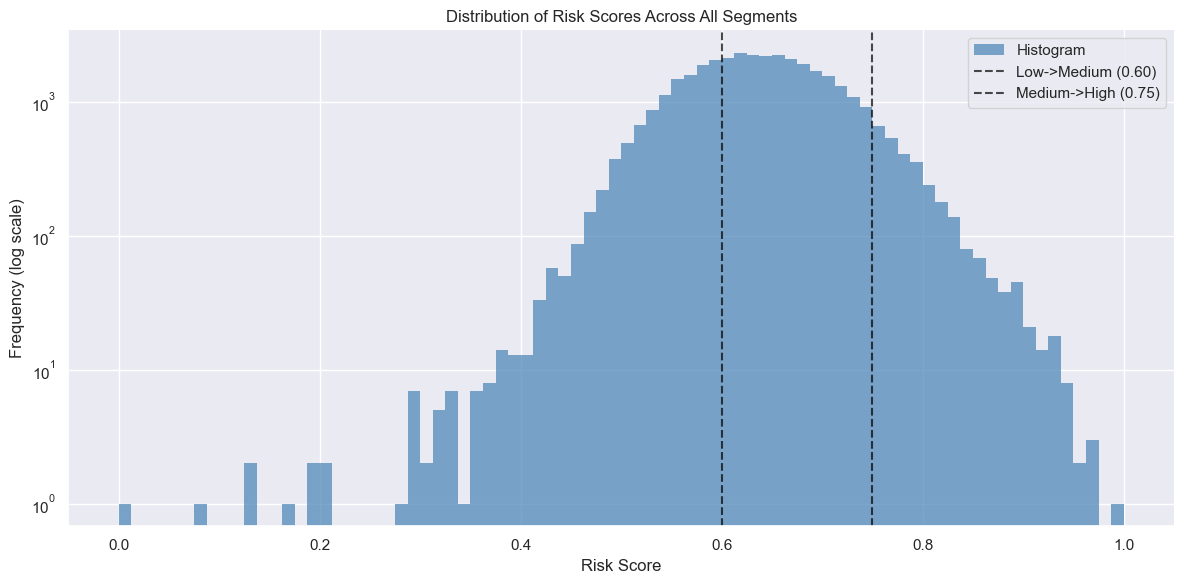

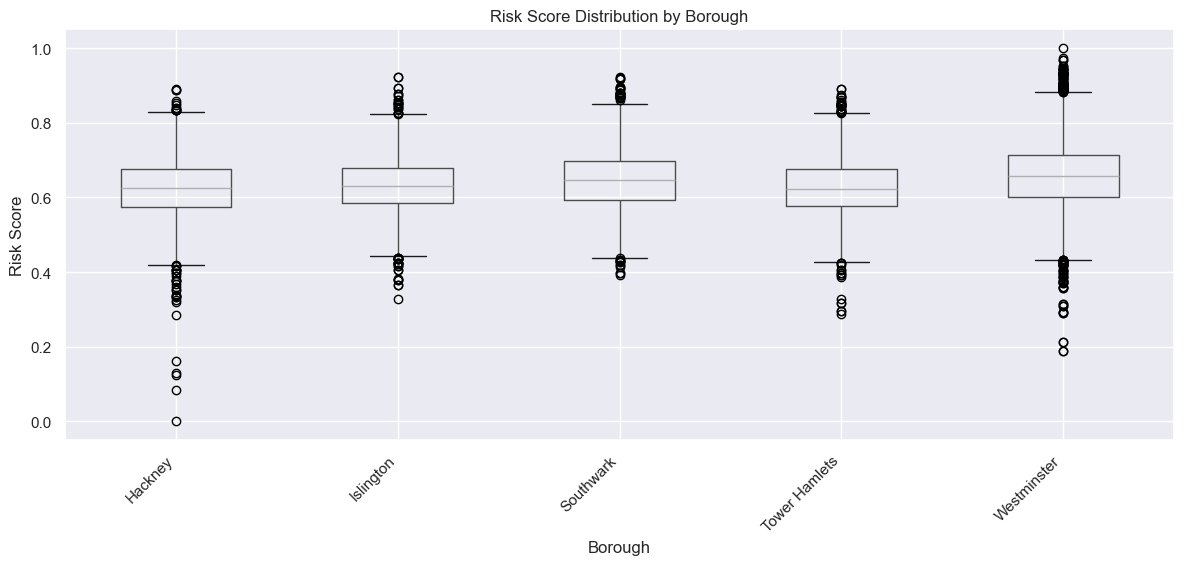

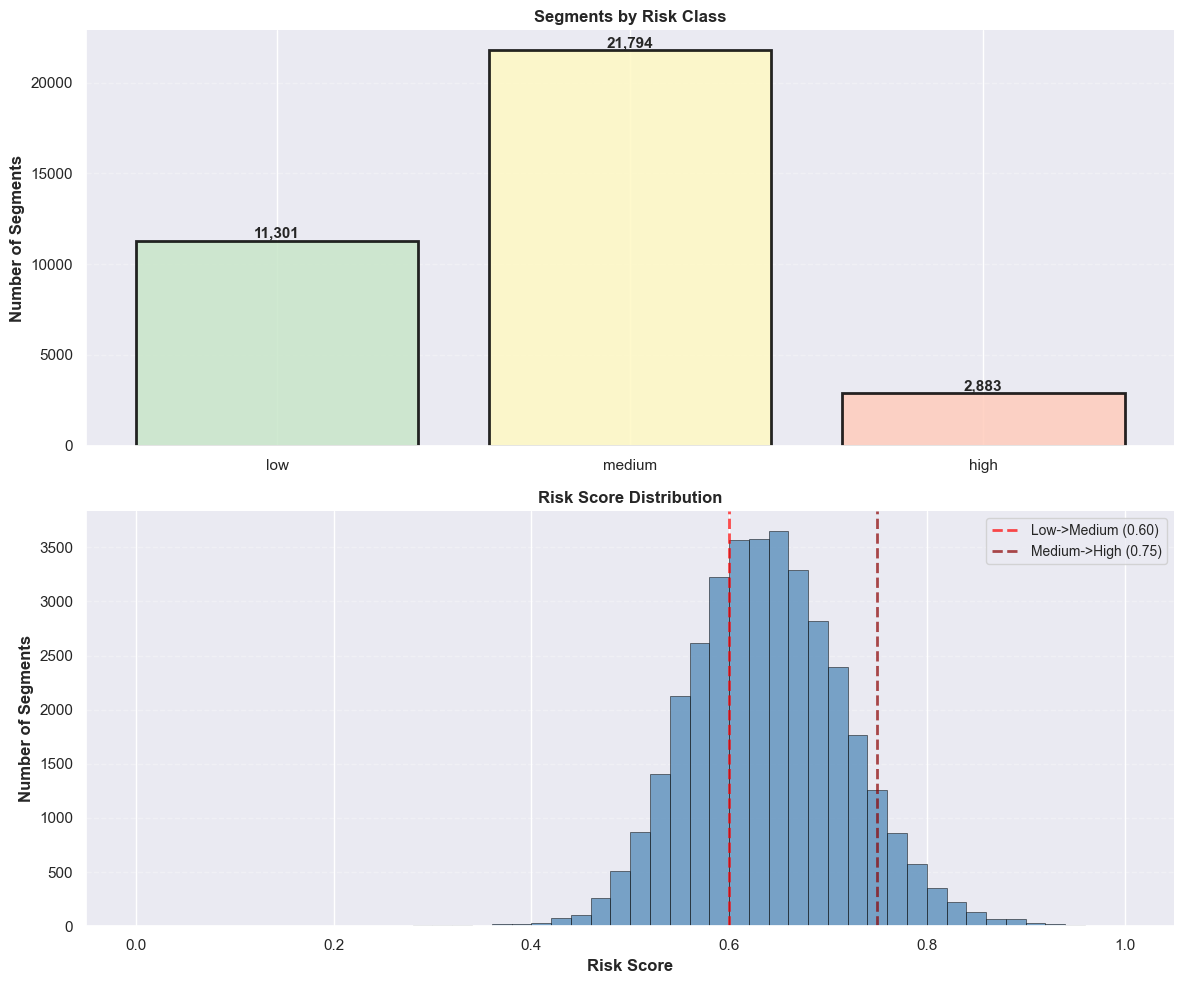

In [15]:
os.makedirs('plots', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(features['risk_score'], bins=80, color='steelblue', alpha=0.7, edgecolor='none', label='Histogram')
ax.set_xlabel('Risk Score')
ax.set_ylabel('Frequency (log scale)')
ax.set_yscale('log')
ax.set_title('Distribution of Risk Scores Across All Segments')
ax.axvline(threshold_low_med, color='black', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Low->Medium ({threshold_low_med:.2f})')
ax.axvline(threshold_med_high, color='black', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Medium->High ({threshold_med_high:.2f})')
ax.set_xlim([features['risk_score'].min() - 0.05, features['risk_score'].max() + 0.05])
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plots/risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
features_copy = features.copy()
features_copy['borough_short'] = (features_copy['borough']
    .str.replace('London Borough of ', '').str.replace(', London, UK', '').str.replace('City of ', ''))
features_copy.boxplot(column='risk_score', by='borough_short', ax=ax)
ax.set_xlabel('Borough'); ax.set_ylabel('Risk Score')
ax.set_title('Risk Score Distribution by Borough')
plt.suptitle(''); plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/risk_score_by_borough.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
class_counts = features['risk_class'].value_counts().reindex(['low', 'medium', 'high'])
colors_list = ['#C8E6C9', '#FFF9C4', '#FFCCBC']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors_list, edgecolor='black',
                   linewidth=2, alpha=0.85)
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Number of Segments', fontsize=12, fontweight='bold')
axes[0].set_title('Segments by Risk Class', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].hist(features['risk_score'], bins=50, color='steelblue', edgecolor='black',
             linewidth=0.5, alpha=0.7)
axes[1].set_xlabel('Risk Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Segments', fontsize=12, fontweight='bold')
axes[1].set_title('Risk Score Distribution', fontsize=12, fontweight='bold')
axes[1].axvline(threshold_low_med, color='red', linestyle='--', linewidth=2, alpha=0.7,
                label=f'Low->Medium ({threshold_low_med:.2f})')
axes[1].axvline(threshold_med_high, color='darkred', linestyle='--', linewidth=2, alpha=0.7,
                label=f'Medium->High ({threshold_med_high:.2f})')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('plots/risk_score_by_class.png', dpi=150, bbox_inches='tight')
plt.show()